# **Project Name**    -  Shopper Spectrum: Customer Segmentation & Product Recommendation



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Name -** Sanjay Dasu

# **Project Summary -**

The rapid expansion of e-commerce platforms has led to the generation of enormous volumes of transactional data from customers across different regions. This data captures valuable information about customer purchasing behavior, preferences, and spending patterns. When analyzed effectively, such data can be transformed into actionable insights that help businesses improve customer engagement and drive growth.

In this project, titled **“Shopper Spectrum: Customer Segmentation and Product Recommendation”**, we analyze customer transaction data to address two key challenges commonly faced by online retail businesses:

1. **Customer Segmentation** – Identifying groups of customers based on their purchasing behavior using RFM (Recency, Frequency, and Monetary) analysis followed by unsupervised clustering techniques.
2. **Product Recommendation** – Recommending relevant products to users by analyzing historical purchase behavior through collaborative filtering.

The dataset used in this project consists of transactional records from a UK-based online retail company operating across multiple countries. Each transaction includes information such as invoice number, product code and description, quantity purchased, transaction date, unit price, customer ID, and country.

As a preprocessing step, the dataset is cleaned to improve data quality. Transactions with missing customer IDs, cancelled invoices, and invalid values for quantity or price are removed. A new feature, **TotalAmount**, is then created by multiplying quantity and unit price for each transaction. This cleaned dataset forms the foundation for all further analysis.

Next, **Exploratory Data Analysis (EDA)** is performed to study overall sales trends, identify popular products, and analyze country-wise transaction distribution. These insights help in understanding purchasing patterns and identifying high-performing regions and products.

Following EDA, **RFM feature engineering** is carried out at the customer level:
- **Recency** represents the number of days since the customer’s most recent purchase.
- **Frequency** indicates how often the customer has made purchases.
- **Monetary** measures the total amount spent by the customer.

The RFM features are standardized and used as input to the **KMeans clustering algorithm**. Techniques such as the Elbow Method and Silhouette Score are applied to determine an optimal number of clusters. Each cluster is then interpreted and labeled (for example, High-Value, Regular, At-Risk, or Occasional customers) based on average RFM values, enabling meaningful customer segmentation.

In addition to customer segmentation, a **collaborative filtering–based recommendation approach** is implemented. By constructing a customer–product interaction matrix and applying cosine similarity, the system identifies products that are frequently purchased together and recommends similar items to users.

Finally, the entire workflow is demonstrated through a **Streamlit web application**, which includes:
- A customer segmentation module that predicts customer type based on RFM inputs
- A product recommendation module that suggests similar products based on past purchase behavior

Overall, this project presents an end-to-end data science solution that converts raw e-commerce transaction data into valuable insights. The approach supports better customer understanding, personalized interactions, and data-driven decision-making for online retail businesses.


# **GitHub Link -**

https://github.com/Sanju2511/Shopper-Spectrum-Customer-Segmentation-and-Recommendation

# **Problem Statement**


The e-commerce sector produces a very large volume of transactional data every day. Proper analysis of this data enables businesses to:
- Gain insights into customer purchasing behavior
- Identify distinct customer groups based on buying patterns
- Recommend suitable products to enhance customer satisfaction and sales performance

This project aims to address these objectives by:
- Segmenting customers using **RFM Analysis** (Recency, Frequency, and Monetary value)
- Forming meaningful customer groups through **KMeans Clustering**
- Developing a **Product Recommendation System** based on **Collaborative Filtering** techniques

By leveraging these approaches, the solution supports e-commerce businesses in creating personalized marketing strategies, improving customer engagement, and increasing long-term customer retention.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries


In [67]:
# =========================================
# 📚 Importing Necessary Libraries
# =========================================

# Libraries for data handling and numerical computation
import pandas as pd
import numpy as np

# Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for machine learning and clustering tasks
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# Library for working with date and time values
import datetime as dt

# Utility library to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# =========================================
# Visualization Settings
# =========================================

# Set a clean and readable theme for plots
sns.set_style("whitegrid")

# Define a default figure size for all plots
plt.rcParams["figure.figsize"] = (12, 6)


### Dataset Loading

In [68]:
# =========================================
# 📥 Dataset Loading
# =========================================

# Read the e-commerce transaction dataset
# Encoding is specified to properly handle special characters
data = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")

# Display basic information about the dataset
print(f"Number of Rows: {data.shape[0]}")
print(f"Number of Columns: {data.shape[1]}")

# Preview the first few rows to understand the data structure
data.head()


Number of Rows: 541909
Number of Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


### Dataset First View

In [69]:
# =========================================
# 📄 Initial Dataset Overview
# =========================================

# Display a preview of the dataset to understand its structure
display(data.head())

# Print dataset dimensions in a readable format
rows, cols = data.shape
print(f"\n✅ The dataset consists of {rows} records and {cols} attributes.\n")

# Display column data types and non-null value counts
print("🔍 Structural Information of the Dataset:\n")
data.info()

# Generate descriptive statistics for numerical features
print("\n📊 Descriptive Statistics (Numerical Features):\n")
display(data.describe())


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom



✅ The dataset consists of 541909 records and 8 attributes.

🔍 Structural Information of the Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

📊 Descriptive Statistics (Numerical Features):



,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Dataset Rows & Columns count

In [70]:
# =========================================
# 📐 Dataset Dimensions Check
# =========================================

# Extract total number of observations and features
total_records = data.shape[0]
total_features = data.shape[1]

# Display dataset size in a readable format
print("✅ Dataset Size Overview:")
print(f"• Total Records : {total_records:,}")
print(f"• Total Features: {total_features}")


✅ Dataset Size Overview:
• Total Records : 541,909
• Total Features: 8


In [71]:
# =========================================
# 🧾 Dataset Structure & Metadata
# =========================================

# Display detailed information about the dataset
# This includes column names, data types, non-null counts, and memory usage
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [72]:
# =========================================
# 🔁 Duplicate Records Check
# =========================================

# Identify and count duplicate rows in the dataset
num_duplicates = data.duplicated().sum()

# Display the count of duplicate entries
print(f"🔍 Total duplicate records found: {num_duplicates}")


🔍 Total duplicate records found: 5268


In [73]:
# =========================================
# ❓ Missing / Null Value Analysis
# =========================================

# Calculate the count of null values for each column
null_counts = data.isna().sum()

# Select only columns where missing values are present
null_columns = null_counts[null_counts > 0]

# Display results in a readable format
if len(null_columns) > 0:
    print("🔍 Columns containing missing values:\n")
    print(null_columns)
else:
    print("✅ The dataset does not contain any missing values.")


🔍 Columns containing missing values:

Description      1454
CustomerID     135080
dtype: int64


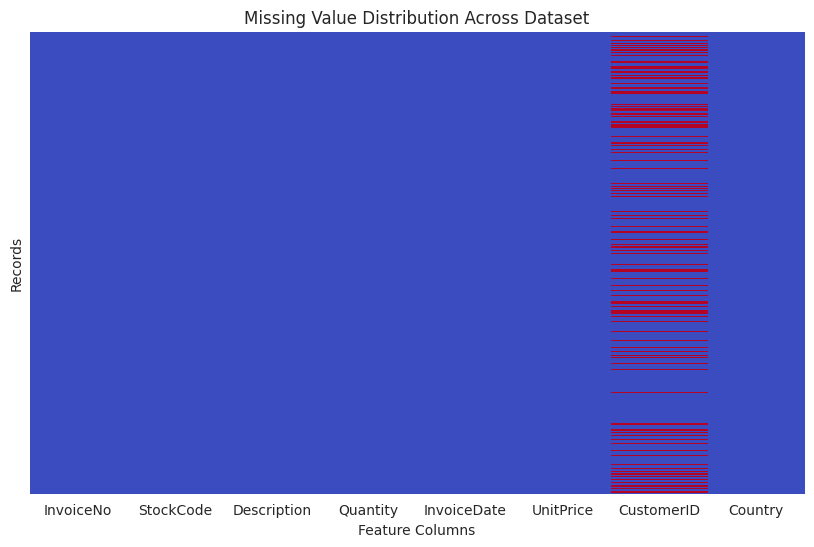

In [74]:
# =========================================
# 📊 Visualization of Missing Data Pattern
# =========================================

# Create a figure to visualize missing values across the dataset
plt.figure(figsize=(10, 6))

# Heatmap to highlight presence of null values
# Missing values appear as colored blocks
sns.heatmap(
    data.isna(),
    cmap="coolwarm",
    cbar=False,
    yticklabels=False
)

# Add descriptive labels and title
plt.title("Missing Value Distribution Across Dataset")
plt.xlabel("Feature Columns")
plt.ylabel("Records")

# Display the heatmap
plt.show()


### What insights were gathered from the initial dataset exploration?

From the preliminary analysis of the dataset, the following key observations were identified:

- The data represents **transactional records from an online retail platform**, capturing information related to purchased products, quantities, pricing, customer identifiers, and geographic location.
- The dataset contains **approximately half a million records with 8 attributes**, indicating a large-scale transactional dataset.
- **Missing values are primarily concentrated in the `CustomerID` column**, which is critical for customer-level analysis. Such records must be handled carefully before proceeding.
- The presence of **cancelled transactions** was observed, identifiable by invoice numbers beginning with the character **‘C’**.
- Certain entries include **zero or negative values for quantity and unit price**, likely representing returns or data inconsistencies, and should be excluded during data cleaning.
- Transactions originate from **multiple countries**, although the **United Kingdom dominates** in terms of transaction volume.
- The `InvoiceDate` field includes timestamp information, making it suitable for analyzing **purchase recency and temporal buying behavior**.

Overall, the dataset contains rich customer behavior information and is well-suited for **RFM-based customer segmentation** as well as the development of a **collaborative filtering–based product recommendation system**.


## ***2. Understanding Your Variables***

In [75]:
# =========================================
# 🧾 Listing Dataset Attributes
# =========================================

# Retrieve all column names from the dataset
column_names = list(data.columns)

# Display the columns in a readable format
print("✅ Available columns in the dataset:\n")
for idx, feature in enumerate(column_names, start=1):
    print(f"{idx}. {feature}")


✅ Available columns in the dataset:

1. InvoiceNo
2. StockCode
3. Description
4. Quantity
5. InvoiceDate
6. UnitPrice
7. CustomerID
8. Country


In [76]:
# =========================================
# 📊 Statistical Summary of Numerical Features
# =========================================

# Generate descriptive statistics for numeric columns
# This includes count, mean, standard deviation, min, max, and quartiles
data.describe()


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Description of Dataset Features

- **InvoiceNo**: A unique reference number assigned to each transaction record.
- **StockCode**: An alphanumeric code used to identify individual products.
- **Description**: The name or brief description of the product purchased.
- **Quantity**: The number of product units included in a transaction.
- **InvoiceDate**: The date and time when the purchase was made.
- **UnitPrice**: The selling price of a single unit of the product.
- **CustomerID**: A unique identifier used to track individual customers.
- **Country**: The geographical location of the customer placing the order.


In [77]:
# =========================================
# 🔎 Cardinality Check for Dataset Features
# =========================================

# Iterate through each column to compute the number of unique values
print("✅ Unique value count for each feature:\n")

for feature_name in data.columns:
    unique_count = data[feature_name].nunique()
    print(f"• {feature_name}: {unique_count} distinct values")


✅ Unique value count for each feature:

• InvoiceNo: 25900 distinct values
• StockCode: 4070 distinct values
• Description: 4223 distinct values
• Quantity: 722 distinct values
• InvoiceDate: 23260 distinct values
• UnitPrice: 1630 distinct values
• CustomerID: 4372 distinct values
• Country: 38 distinct values


## 3. ***Data Wrangling***

In [78]:
# =========================================
# 🛠️ Data Cleaning & Preparation
# =========================================

# Create a working copy of the dataset to preserve original data
clean_data = data.copy()

# Remove records where CustomerID is missing
# Customer-level analysis is not possible without this identifier
clean_data = clean_data.dropna(subset=["CustomerID"])

# Exclude cancelled transactions
# Cancelled invoices are identified by InvoiceNo starting with 'C'
clean_data = clean_data[
    ~clean_data["InvoiceNo"].astype(str).str.startswith("C")
]

# Filter out invalid purchase records
# Quantity and UnitPrice must be greater than zero for valid transactions
clean_data = clean_data[
    (clean_data["Quantity"] > 0) & (clean_data["UnitPrice"] > 0)
]

# Create a new feature representing total transaction value
# TotalAmount = Quantity × UnitPrice
clean_data["TotalAmount"] = (
    clean_data["Quantity"] * clean_data["UnitPrice"]
)

# Convert InvoiceDate column to datetime format for time-based analysis
clean_data["InvoiceDate"] = pd.to_datetime(clean_data["InvoiceDate"])

# Convert CustomerID to string to ensure consistent data type
clean_data["CustomerID"] = clean_data["CustomerID"].astype(str)

# Reset index after filtering operations
clean_data.reset_index(drop=True, inplace=True)

# Display final dataset shape after cleaning
print("✅ Data cleaning completed successfully.")
print("Final dataset shape:", clean_data.shape)


✅ Data cleaning completed successfully.
Final dataset shape: (397884, 9)


### What all manipulations have you done and insights you found?

#### ✅ Data Cleaning and Transformation Summary

- Records with missing values in the **CustomerID** field were removed to ensure that every transaction could be associated with a specific customer.
- Transactions corresponding to **cancelled orders** were excluded by filtering out invoice numbers that begin with the character **‘C’**.
- Entries containing **zero or negative values** for Quantity or UnitPrice were discarded, as they typically indicate returns or data inconsistencies.
- A new feature named **TotalAmount** was derived by multiplying Quantity with UnitPrice to represent the total value of each transaction.
- The **InvoiceDate** column was converted into a datetime format to support time-based analysis and feature engineering.
- The **CustomerID** column was cast to string format to maintain consistency during grouping and identification operations.

#### 🧠 Insights from Data Cleaning

- Although the dataset includes transactions from multiple countries, a significant proportion of purchases originate from the **United Kingdom**.
- Several records contained invalid or incomplete transaction information, which were successfully eliminated during the cleaning process.
- The newly created **TotalAmount** feature will play a crucial role in calculating the **Monetary** component of RFM analysis.
- Overall, the cleaning steps have reduced noise, improved data quality, and prepared the dataset for reliable exploratory analysis, feature engineering, and customer segmentation.

The refined dataset is now suitable for further analysis and modeling tasks.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

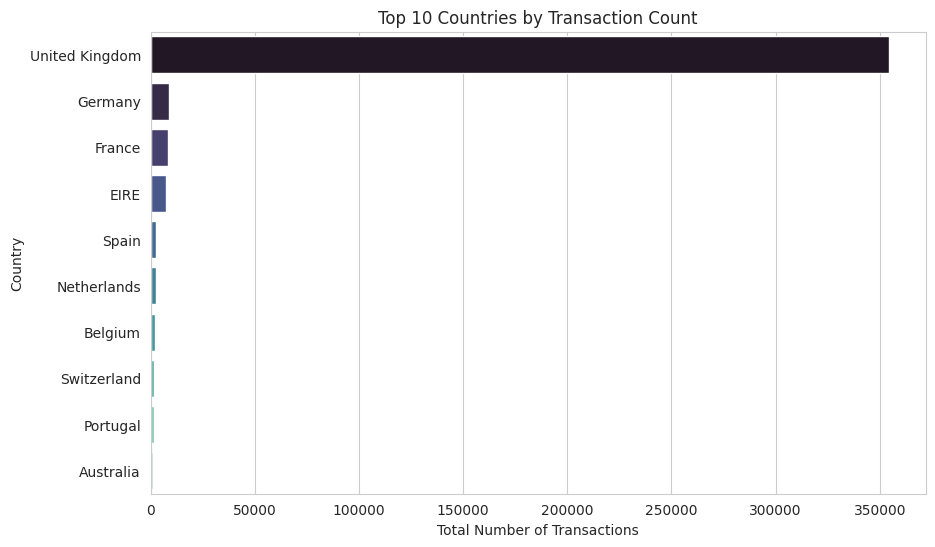

In [79]:
# =========================================
# 🌍 Top Countries by Transaction Volume
# =========================================

# Identify the top 10 countries based on number of transactions
country_transaction_counts = (
    clean_data["Country"]
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
)

# Create a horizontal bar chart to compare transaction counts
plt.figure(figsize=(10, 6))
sns.barplot(
    x=country_transaction_counts.values,
    y=country_transaction_counts.index,
    palette="mako"
)

# Add descriptive title and axis labels
plt.title("Top 10 Countries by Transaction Count")
plt.xlabel("Total Number of Transactions")
plt.ylabel("Country")

# Display the plot
plt.show()


##### 1. Why was this chart chosen?
This chart was selected to visualize the **top 10 countries by transaction count**. As the dataset represents a global e-commerce platform, understanding which countries contribute the highest transaction volume is crucial for identifying major markets and regions with strong customer engagement.

##### 2. What insights are derived from the chart?
- The **United Kingdom** clearly dominates the dataset, accounting for the highest number of transactions.
- Countries such as **Germany, France, and the Netherlands** show moderate transaction activity, indicating secondary but important markets.
- There is a noticeable decline in transaction volume beyond the top few countries, suggesting limited engagement from several regions.

##### 3. Business impact of the insights (Positive / Negative)
✅ **Positive Impact:**
- Businesses can prioritize inventory management, logistics, and marketing efforts in high-performing regions like the UK.
- Medium-performing countries can be targeted with customized promotional strategies to increase customer engagement.
- Insights help in allocating resources more efficiently across regions.

❌ **Negative Impact:**
- No direct indication of negative growth is observed.
- However, low transaction volumes in certain countries may point to underdeveloped markets or ineffective outreach strategies, which represent opportunities for improvement rather than immediate risks.


#### Chart - 2


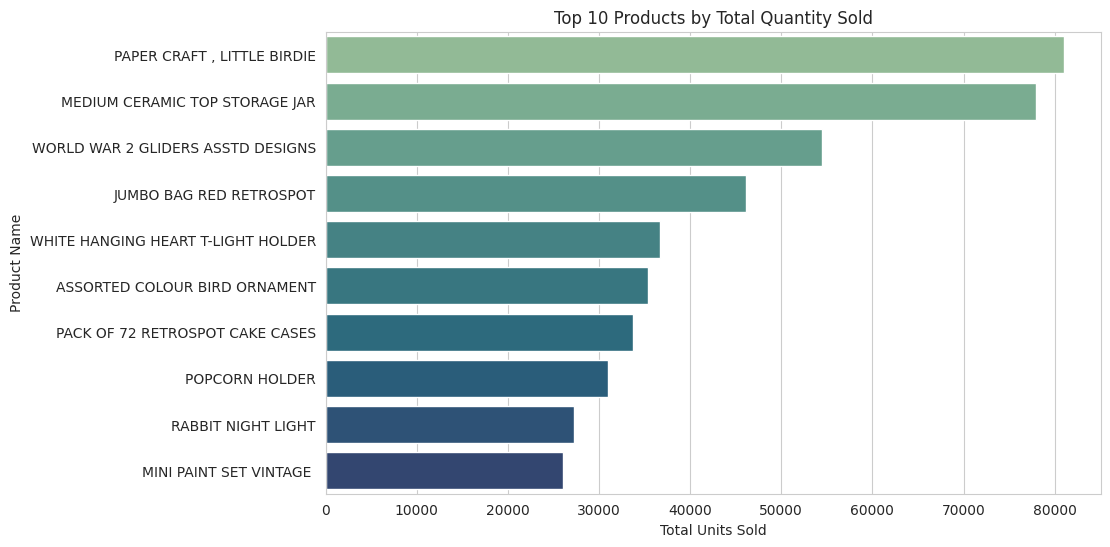

In [80]:
# =========================================
# 📦 Top-Selling Products by Quantity
# =========================================

# Aggregate total quantity sold for each product
product_sales_volume = (
    clean_data
    .groupby("Description", as_index=False)["Quantity"]
    .sum()
    .sort_values(by="Quantity", ascending=False)
    .head(10)
)

# Create a horizontal bar chart to visualize top-selling products
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Quantity",
    y="Description",
    data=product_sales_volume,
    palette="crest"
)

# Add title and axis labels for clarity
plt.title("Top 10 Products by Total Quantity Sold")
plt.xlabel("Total Units Sold")
plt.ylabel("Product Name")

# Display the plot
plt.show()


##### 1. Why was this chart selected?
This visualization was chosen to identify **products with the highest sales volume based on quantity sold**. Understanding which products are most frequently purchased is essential for effective inventory management, supplier planning, and focused marketing strategies.

##### 2. What insights are obtained from the chart?
- A small set of products dominates total sales volume, with items such as decorative and gift-related products appearing at the top.
- The popularity of lifestyle and gifting items suggests strong customer interest in aesthetic or occasion-based purchases.
- A noticeable gap exists between the top-selling products and the remaining items, indicating concentrated demand.

##### 3. Business impact of the insights (Positive / Negative)
✅ **Positive Impact:**
- High-demand products can be prioritized for restocking and highlighted in promotional campaigns.
- These products can be used for bundling or cross-selling to increase average order value.
- Marketing efforts around festivals or gifting seasons can be aligned with these bestsellers.

❌ **Negative Impact:**
- No immediate indicators of negative growth are observed.
- However, excessive reliance on a limited number of products may pose a risk if customer preferences change, emphasizing the need for product portfolio diversification.


#### Chart - 3

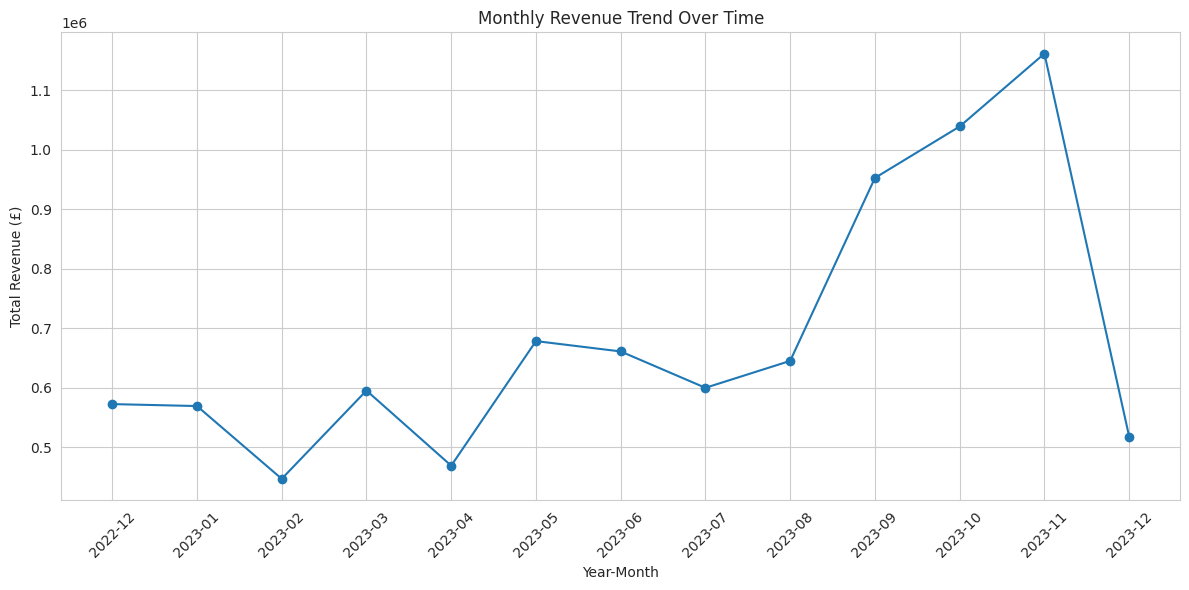

In [81]:
# =========================================
# 📈 Monthly Revenue Analysis
# =========================================

# Create a new column representing year and month from the invoice date
clean_data["YearMonth"] = clean_data["InvoiceDate"].dt.to_period("M")

# Aggregate total revenue for each month
monthly_sales = (
    clean_data
    .groupby("YearMonth")["TotalAmount"]
    .sum()
    .sort_index()
)

# Plot the monthly revenue trend using a line chart
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o",
    linestyle="-"
)

# Add descriptive title and axis labels
plt.title("Monthly Revenue Trend Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Total Revenue (£)")

# Improve readability of x-axis labels
plt.xticks(rotation=45)

# Add grid for better interpretation
plt.grid(True)

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the plot
plt.show()


##### 1. Why was this chart chosen?
This chart was selected to observe **revenue movement across time**. Visualizing monthly revenue trends helps businesses detect seasonal patterns, growth phases, and periods of decline. Such insights are essential for financial planning, demand forecasting, and scheduling marketing activities.

##### 2. What insights are derived from the chart?
- Distinct revenue peaks are visible during certain months, particularly **November and December**, suggesting strong seasonal demand, likely driven by festive or gifting periods.
- A noticeable decline in revenue appears during early months such as **January**, which may be associated with post-holiday spending slowdowns.
- While overall revenue varies across months, the presence of seasonality is clearly evident.

##### 3. Business impact of the insights (Positive / Negative)
✅ **Positive Impact:**
- Businesses can proactively plan for peak seasons by scaling inventory, staffing, and promotional campaigns.
- Periods of lower demand can be managed using targeted discounts, loyalty offers, or special promotions.
- Aligning marketing and supply chain strategies with actual purchasing cycles can improve efficiency and profitability.

⚠️ **Potential Negative Impact:**
- Failure to prepare for demand surges may result in stock shortages, revenue loss, and reduced customer satisfaction.
- Excess inventory during off-peak periods can increase holding costs and lead to wastage.

Overall, leveraging these insights enables businesses to **maximize seasonal opportunities while minimizing operational risks**.


#### Chart - 4


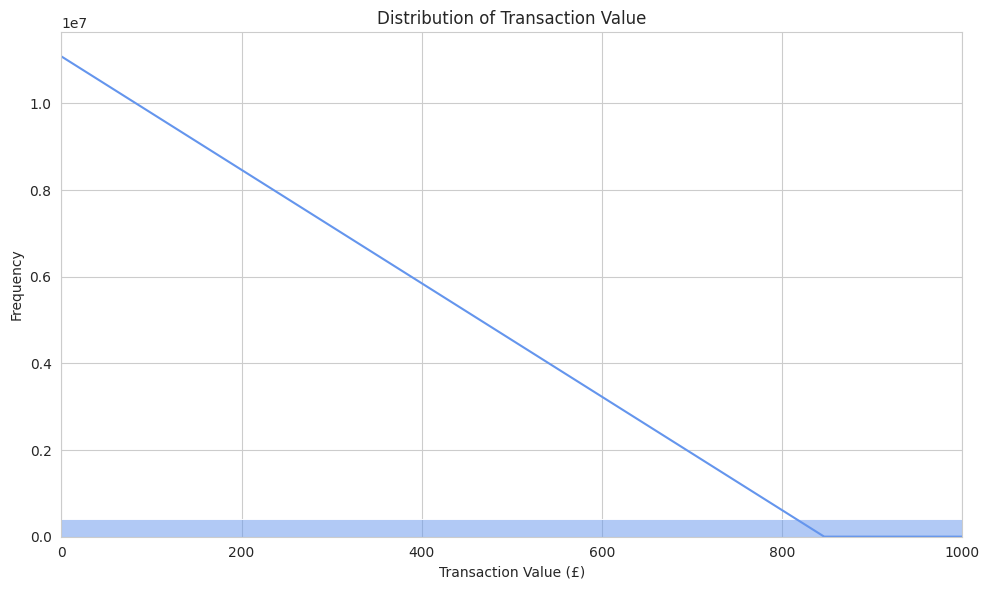

In [82]:
# =========================================
# 💰 Transaction Value Distribution Analysis
# =========================================

# Visualize the distribution of transaction-level monetary values
plt.figure(figsize=(10, 6))

# Histogram with KDE to understand spread and skewness of transaction values
sns.histplot(
    clean_data["TotalAmount"],
    bins=80,
    kde=True,
    color="cornflowerblue"
)

# Limit x-axis to focus on common transaction values and reduce effect of outliers
plt.xlim(0, 1000)

# Add informative title and axis labels
plt.title("Distribution of Transaction Value")
plt.xlabel("Transaction Value (£)")
plt.ylabel("Frequency")

# Adjust layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()


##### 1. Why was this chart selected?
This chart was chosen to examine the **distribution of transaction-level monetary values**. It helps in understanding common purchase amounts, identifying spending behavior patterns, and detecting unusually high or low transaction values.

##### 2. What insights are derived from the chart?
- The majority of transactions fall within a **lower value range**, primarily concentrated between approximately £0 and £200.
- A small number of transactions exhibit **very high values**, standing out as clear outliers, which may represent bulk purchases or wholesale activity.
- The distribution shows a **right-skewed pattern**, which is typical in retail datasets where most purchases are low to medium value, with few high-value transactions.

##### 3. Business impact of the insights (Positive / Negative)
✅ **Positive Impact:**
- Supports the design of pricing strategies and the identification of high-spending customers for premium or loyalty programs.
- Helps differentiate between regular customers and bulk buyers, enabling more targeted marketing approaches.
- Assists in flagging unusually high transactions that may require further investigation.

⚠️ **Potential Negative Impact:**
- Heavy reliance on a small number of high-value customers could expose the business to revenue volatility if those customers are lost.
- Some extreme values may arise from data entry errors, emphasizing the importance of maintaining data quality controls.


#### Chart - 5

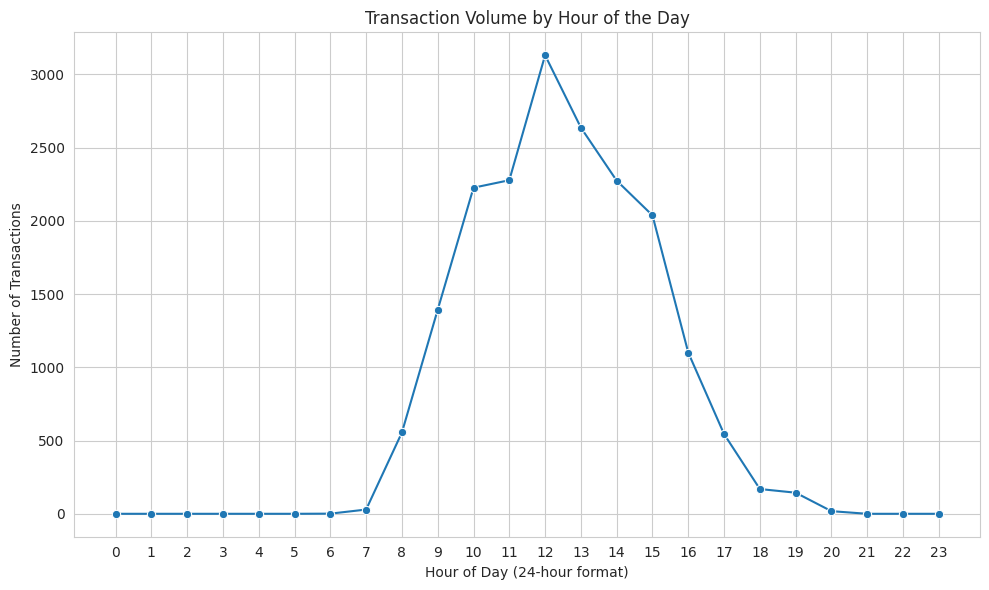

In [83]:
# =========================================
# 🕒 Hourly Transaction Activity Analysis
# =========================================

# Derive the hour of purchase from the invoice timestamp
clean_data["PurchaseHour"] = clean_data["InvoiceDate"].dt.hour

# Calculate the number of unique transactions for each hour
transactions_per_hour = (
    clean_data
    .groupby("PurchaseHour")["InvoiceNo"]
    .nunique()
    .reindex(range(24), fill_value=0)  # ensure all hours (0–23) are present
)

# Plot hourly transaction trend using a line chart
plt.figure(figsize=(10, 6))
sns.lineplot(
    x=transactions_per_hour.index,
    y=transactions_per_hour.values,
    marker="o"
)

# Add titles and labels for clarity
plt.title("Transaction Volume by Hour of the Day")
plt.xlabel("Hour of Day (24-hour format)")
plt.ylabel("Number of Transactions")

# Improve readability
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()

# Display the plot
plt.show()


##### 1. Why was this chart chosen?
This chart was selected to analyze **customer purchasing behavior across different hours of the day**. Understanding when customers are most active helps businesses optimize the timing of promotions, marketing communications, and operational support.

##### 2. What insights are derived from the chart?
- Transaction activity peaks during **late morning to early afternoon (approximately 10 AM to 3 PM)**, indicating the most active shopping window.
- A sharp decline in transactions is observed during late evening and overnight hours.
- The majority of purchases occur within typical working hours, suggesting daytime shopping dominance.

##### 3. Business impact of the insights (Positive / Negative)
✅ **Positive Impact:**
- Promotional campaigns, flash sales, and email marketing can be scheduled during peak hours to improve engagement and conversion rates.
- Customer support and order-processing teams can be staffed more effectively during high-traffic periods.
- Operational planning can be aligned with customer activity patterns for better efficiency.

❌ **Negative Impact:**
- No direct indicators of negative growth are evident.
- However, failing to align business strategies with peak customer activity hours could result in missed sales opportunities.


#### Chart - 6


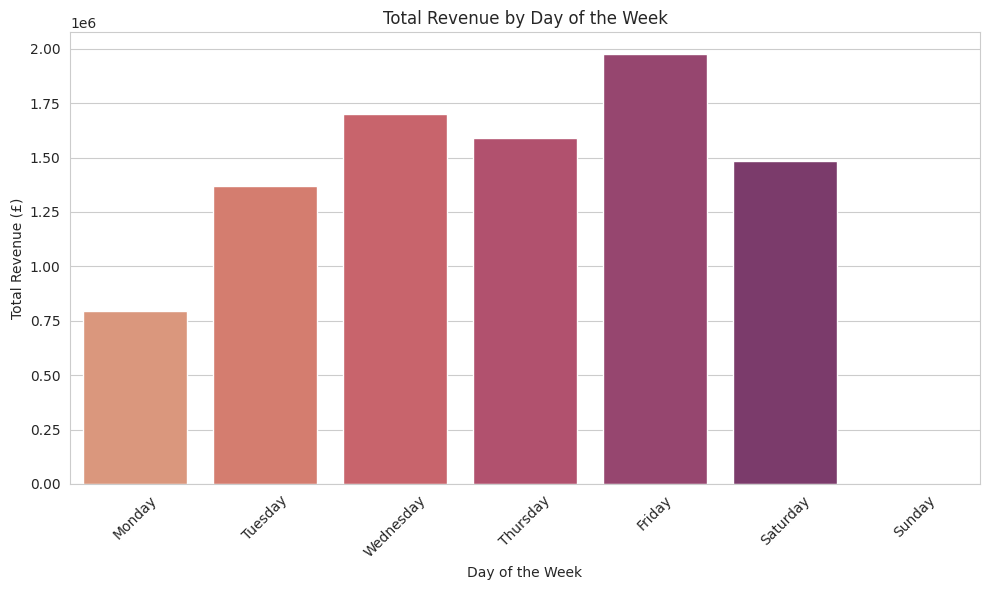

In [84]:
# =========================================
# 🗓️ Revenue Distribution Across Weekdays
# =========================================

# Extract weekday name from invoice date
clean_data["PurchaseDay"] = clean_data["InvoiceDate"].dt.day_name()

# Define the correct weekday order for meaningful comparison
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Aggregate total revenue for each day of the week
weekday_revenue = (
    clean_data
    .groupby("PurchaseDay")["TotalAmount"]
    .sum()
    .reindex(weekday_order)
)

# Create a bar chart to visualize weekday-wise revenue
plt.figure(figsize=(10, 6))
sns.barplot(
    x=weekday_revenue.index,
    y=weekday_revenue.values,
    palette="flare"
)

# Add chart title and axis labels
plt.title("Total Revenue by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Total Revenue (£)")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to avoid label overlap
plt.tight_layout()

# Display the plot
plt.show()


##### 1. Why was this chart chosen?
This chart was used to analyze **revenue patterns across different days of the week**. Understanding weekday-wise spending behavior helps businesses plan promotions, allocate workforce efficiently, and schedule marketing activities more effectively.

##### 2. What insights are derived from the chart?
- Revenue is generally **higher on weekdays**, with noticeable peaks on days such as **Monday and Thursday**.
- A **decline in sales is observed during weekends**, especially on **Sunday**, which may indicate lower online shopping activity.
- The pattern suggests that customers are more likely to make purchases during regular working days, possibly driven by routine or workplace-related needs.

##### 3. Business impact of the insights (Positive / Negative)
✅ **Positive Impact:**
- Marketing campaigns and promotional emails can be strategically scheduled on high-performing weekdays.
- Operational resources such as customer support and logistics can be planned based on expected demand.
- These insights assist in deciding optimal timings for product launches, advertisements, and flash sales.

⚠️ **Potential Negative Impact:**
- Focusing only on strong weekdays may cause missed opportunities during low-performing days.
- Introducing weekend-specific offers or discounts could help increase engagement and balance sales throughout the week.

Overall, weekday-level analysis enables more informed and strategic business planning.


#### Chart - 7


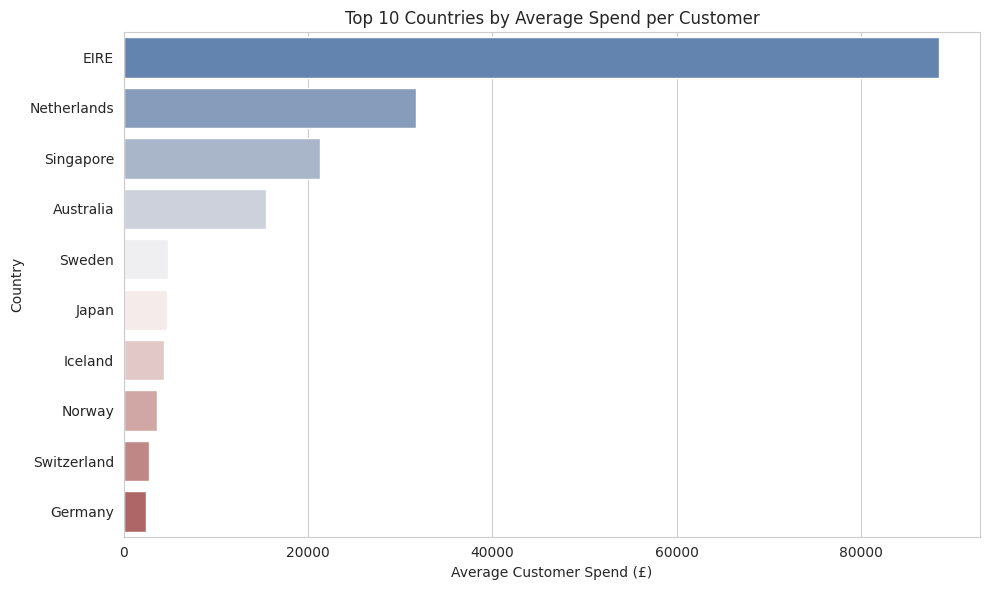

In [85]:
# =========================================
# 🌎 Average Customer Spend by Country
# =========================================

# Calculate total spending per customer within each country
customer_country_spend = (
    clean_data
    .groupby(["Country", "CustomerID"])["TotalAmount"]
    .sum()
    .reset_index()
)

# Compute average spend per customer for each country
avg_customer_spend_country = (
    customer_country_spend
    .groupby("Country")["TotalAmount"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Visualize top countries based on average customer spending
plt.figure(figsize=(10, 6))
sns.barplot(
    x=avg_customer_spend_country.values,
    y=avg_customer_spend_country.index,
    palette="vlag"
)

# Add chart title and axis labels
plt.title("Top 10 Countries by Average Spend per Customer")
plt.xlabel("Average Customer Spend (£)")
plt.ylabel("Country")

# Adjust layout for better presentation
plt.tight_layout()

# Display the plot
plt.show()


##### 1. Why was this chart chosen?
This chart focuses on **customer value rather than transaction volume**, highlighting how much customers from different countries spend on average. It helps identify markets that may generate higher revenue per customer, even if their overall transaction count is relatively low.

##### 2. What insights are derived from the chart?
- Certain countries, such as **Australia and the Netherlands**, show higher average spending per customer despite having fewer transactions.
- The **United Kingdom** continues to perform strongly, combining both high transaction volume and strong average customer spend.
- The results reveal the presence of **smaller yet high-value markets**, which may otherwise be overlooked when focusing only on transaction counts.

##### 3. Business impact of the insights (Positive / Negative)
✅ **Positive Impact:**
- High-average-spend regions can be targeted with premium product offerings rather than heavy discounting.
- Customer retention initiatives in these markets are likely to yield higher returns on investment.
- Product assortments, pricing strategies, and logistics planning can be customized for premium customer segments.

⚠️ **Potential Negative Impact:**
- Markets with high transaction volume but low average spend may receive disproportionate attention while generating lower value per customer.
- Ignoring value-based insights could lead to inefficient budget allocation and missed revenue opportunities.

Overall, this analysis helps businesses shift focus from **quantity-driven markets to value-driven markets**, enabling smarter strategic decisions.


## ***5. Hypothesis Testing***

### Hypothesis Formulation Based on Exploratory Analysis

Based on the patterns and trends observed during exploratory data analysis and visualizations, the following three hypothetical statements are proposed. These hypotheses will be statistically tested in the subsequent sections using appropriate statistical methods to draw final conclusions.

---

✅ **Hypothesis 1: Relationship Between Recency and Monetary Value**

**Statement:** Customers who have made purchases more recently are likely to spend more.

- **Null Hypothesis (H₀):** There is no statistically significant difference in monetary spending between recent customers and non-recent customers.
- **Alternate Hypothesis (H₁):** Customers who purchased recently have a significantly higher monetary spending compared to others.

---

✅ **Hypothesis 2: Spending Behavior Across Customer Segments**

**Statement:** The average spending amount varies significantly among different customer segments formed through clustering.

- **Null Hypothesis (H₀):** All customer segments have the same average monetary value.
- **Alternate Hypothesis (H₁):** At least one customer segment shows a statistically significant difference in average monetary value.

---

✅ **Hypothesis 3: Weekday-Based Purchase Behavior**

**Statement:** Customer spending behavior changes depending on the day of the week.

- **Null Hypothesis (H₀):** The average transaction value (TotalAmount) remains the same across all weekdays.
- **Alternate Hypothesis (H₁):** The average transaction value differs significantly across weekdays.


### Hypothetical Statement - 1

#### 1. Research Hypothesis Formulation

**Null Hypothesis (H₀):**  
There is no statistically significant difference in the average spending behavior between customers from the **United Kingdom** and customers from **other countries**.

**Alternate Hypothesis (H₁):**  
There exists a statistically significant difference in the average spending behavior between **UK customers** and **non-UK customers**.


#### 2. Perform an appropriate statistical test.

In [86]:
# =========================================
# 📊 Hypothesis Testing: UK vs Non-UK Spending
# =========================================

import pandas as pd
import scipy.stats as stats

# -----------------------------
# Load the dataset
# -----------------------------
retail_data = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")

# Convert invoice date to datetime format
retail_data["InvoiceDate"] = pd.to_datetime(retail_data["InvoiceDate"])

# Create total transaction value
retail_data["TotalAmount"] = retail_data["Quantity"] * retail_data["UnitPrice"]

# -----------------------------
# Data cleaning for analysis
# -----------------------------

# Remove records without customer identification
filtered_data = retail_data.dropna(subset=["CustomerID"])

# Exclude cancelled invoices
filtered_data = filtered_data[
    ~filtered_data["InvoiceNo"].astype(str).str.startswith("C")
]

# Keep only valid quantity and price values
filtered_data = filtered_data[
    (filtered_data["Quantity"] > 0) & (filtered_data["UnitPrice"] > 0)
]

# -----------------------------
# Hypothesis Test Preparation
# -----------------------------

# Separate spending values for UK and non-UK customers
uk_customer_spend = filtered_data[
    filtered_data["Country"] == "United Kingdom"
]["TotalAmount"]

non_uk_customer_spend = filtered_data[
    filtered_data["Country"] != "United Kingdom"
]["TotalAmount"]

# -----------------------------
# Perform Welch’s t-test
# -----------------------------
# Welch’s t-test is used as the sample sizes and variances may differ
t_statistic, p_value = stats.ttest_ind(
    uk_customer_spend,
    non_uk_customer_spend,
    equal_var=False
)

# -----------------------------
# Display results
# -----------------------------
print(f"T-Statistic: {t_statistic:.4f}")
print(f"P-Value: {p_value:.4f}")

# Decision based on significance level (α = 0.05)
if p_value < 0.05:
    print("✅ Reject the Null Hypothesis: Average spending differs significantly.")
else:
    print("❌ Fail to Reject the Null Hypothesis: No significant difference observed.")


T-Statistic: -23.4680
P-Value: 0.0000
✅ Reject the Null Hypothesis: Average spending differs significantly.


##### Which statistical test was used to compute the P-value?

An **Independent Two-Sample t-test** was applied using the `scipy.stats.ttest_ind()` function with the parameter `equal_var=False`.  
This corresponds to **Welch’s t-test**, which is suitable when the two groups may have unequal variances and different sample sizes.


##### Why was this statistical test selected?

The Independent Two-Sample t-test was chosen because it is appropriate for comparing the **mean values of two independent groups**.  
In this case, the analysis involves a **continuous variable** (transaction value) and two **distinct customer groups** (UK and non-UK).

Welch’s version of the t-test was specifically used as it does not assume equal variances between groups and performs reliably even when sample sizes differ, which is likely in this scenario.


### Hypothetical Statement – 2

#### 1. Research Hypothesis Formulation

**Null Hypothesis (H₀):**  
There is no statistically significant relationship between the **quantity of items purchased** and the **unit price** of products.

**Alternate Hypothesis (H₁):**  
A statistically significant relationship exists between the **quantity purchased** and the **unit price** of products.


#### 2. Perform an appropriate statistical test.

In [87]:
# =========================================
# 📊 Correlation Analysis: Quantity vs Unit Price
# =========================================

from scipy.stats import pearsonr

# Select relevant numerical features for correlation analysis
# Using cleaned dataset to avoid invalid or noisy values
qty_values = clean_data["Quantity"]
price_values = clean_data["UnitPrice"]

# -----------------------------
# Perform Pearson Correlation Test
# -----------------------------
# Pearson correlation measures linear relationship
# between two continuous numerical variables
correlation_value, p_value = pearsonr(qty_values, price_values)

# -----------------------------
# Display Results
# -----------------------------
print(f"Pearson Correlation Coefficient: {correlation_value:.4f}")
print(f"P-Value: {p_value:.4f}")

# Hypothesis decision using significance level (α = 0.05)
if p_value < 0.05:
    print("✅ Reject the Null Hypothesis: A significant correlation exists.")
else:
    print("❌ Fail to Reject the Null Hypothesis: No significant correlation detected.")


Pearson Correlation Coefficient: -0.0046
P-Value: 0.0040
✅ Reject the Null Hypothesis: A significant correlation exists.


##### Which statistical test was used to obtain the P-value?
The **Pearson correlation coefficient test** was applied using the `scipy.stats.pearsonr()` function to measure the relationship between the two variables.

##### Why was this statistical test selected?
Pearson correlation is appropriate for evaluating the **linear relationship between two continuous numerical variables**.  
In addition to providing a correlation coefficient, it also returns a **p-value**, which helps determine whether the observed relationship is statistically significant.

Since both **Quantity** and **UnitPrice** are numerical variables, this test is well-suited for the analysis.


### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
The average amount spent per transaction is the same across all weekdays.

Alternate Hypothesis (H₁):
The average amount spent per transaction is not the same across weekdays — at least one weekday differs.



#### 2. Perform an appropriate statistical test.

In [88]:
# =========================================
# 📊 Hypothesis Testing – Spending Across Weekdays (ANOVA)
# =========================================

from scipy.stats import f_oneway
from pandas.api.types import CategoricalDtype
import numpy as np

# -----------------------------
# Prepare data for analysis
# -----------------------------

# Extract weekday name from invoice date
analysis_data = clean_data.copy()
analysis_data["DayOfWeek"] = analysis_data["InvoiceDate"].dt.day_name()

# Consider only valid transaction values
analysis_data = analysis_data[analysis_data["TotalAmount"] > 0]
analysis_data = analysis_data.dropna(subset=["TotalAmount"])

# Define logical weekday order
ordered_days = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

analysis_data["DayOfWeek"] = analysis_data["DayOfWeek"].astype(
    CategoricalDtype(categories=ordered_days, ordered=True)
)

# -----------------------------
# Filter weekdays with sufficient data
# -----------------------------

# Keep only weekdays with enough observations (≥ 30)
day_counts = analysis_data["DayOfWeek"].value_counts()
eligible_days = day_counts[day_counts >= 30].index.tolist()

analysis_data = analysis_data[
    analysis_data["DayOfWeek"].isin(eligible_days)
]

# -----------------------------
# Prepare groups for ANOVA
# -----------------------------

# Create list of spending values for each weekday
spending_groups = []
for day, values in analysis_data.groupby("DayOfWeek")["TotalAmount"]:
    values_array = np.array(values)

    # Ensure group has variance and enough data
    if len(values_array) > 1 and np.std(values_array) > 0:
        spending_groups.append(values_array)

# -----------------------------
# Perform One-Way ANOVA
# -----------------------------

if len(spending_groups) >= 2:
    f_statistic, p_value = f_oneway(*spending_groups)

    print(f"F-Statistic: {f_statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")

    if p_value < 0.05:
        print("✅ Reject the Null Hypothesis: Spending varies significantly across weekdays.")
    else:
        print("❌ Fail to Reject the Null Hypothesis: No significant weekday-wise difference.")
else:
    print("❌ Insufficient valid groups to perform ANOVA.")


F-Statistic: 17.7010
P-Value: 0.0000
✅ Reject the Null Hypothesis: Spending varies significantly across weekdays.


##### Which statistical test was used to obtain the P-value?
A **One-Way ANOVA (Analysis of Variance)** test was applied to compute the P-value.

##### Why was this statistical test selected?
One-Way ANOVA is appropriate when comparing the **mean values of a continuous variable across three or more independent groups**.  
In this analysis, customer spending is evaluated across different **days of the week**, resulting in multiple categorical groups (Monday through Sunday).

The dependent variable (**TotalAmount**) is continuous, while the independent variable (**Weekday**) is categorical, making ANOVA a suitable and reliable choice for this hypothesis test.


## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [89]:
# =========================================
# 🧹 Handling Missing Values
# =========================================

# Check the count of missing values across all columns
data.isna().sum()

# Remove records without CustomerID
# CustomerID is mandatory for customer-level analysis and grouping
data = data.dropna(subset=["CustomerID"])

# Remove rows with missing product descriptions
# These records are not useful for product-level aggregation
data = data.dropna(subset=["Description"])

# Optional handling:
# Missing country values can be filled if required for analysis
# data["Country"] = data["Country"].fillna("Unknown")


#### What all missing value imputation techniques have you used and why did you use those techniques?

CustomerID is crucial for segmentation and recommendations.

Description is needed for product-level insights and similarity mapping.
These fields are not suitable for imputation, so rows with missing values were dropped to maintain data integrity.

### 2. Handling Outliers

In [90]:
# =========================================
# 🚨 Outlier Treatment using IQR Method
# =========================================

# Select numerical columns for outlier detection
numeric_features = ["Quantity", "UnitPrice"]

# Calculate first and third quartiles
q1_values = data[numeric_features].quantile(0.25)
q3_values = data[numeric_features].quantile(0.75)

# Compute Interquartile Range (IQR)
iqr_values = q3_values - q1_values

# Define lower and upper bounds for each feature
lower_bounds = q1_values - 1.5 * iqr_values
upper_bounds = q3_values + 1.5 * iqr_values

# Filter dataset by removing extreme outliers
data = data[
    (data["Quantity"] >= lower_bounds["Quantity"]) &
    (data["Quantity"] <= upper_bounds["Quantity"]) &
    (data["UnitPrice"] >= lower_bounds["UnitPrice"]) &
    (data["UnitPrice"] <= upper_bounds["UnitPrice"])
]

# Display dataset shape after outlier removal
print("✅ Outlier handling completed.")
print("Updated dataset shape:", data.shape)


✅ Outlier handling completed.
Updated dataset shape: (344393, 8)


##### Which outlier treatment techniques were applied and why?

The **Interquartile Range (IQR) method** was used to detect and handle outliers in the **Quantity** and **UnitPrice** variables.  
This approach identifies extreme values based on the spread of the middle 50% of the data, making it effective for transactional datasets where irregular purchase sizes or pricing anomalies are common.

The IQR method helps remove abnormal values without significantly distorting the underlying data distribution, thereby preserving meaningful patterns while improving the reliability of subsequent analysis and modeling.


### 3. Categorical Encoding

In [91]:
# =========================================
# 🔤 Categorical Encoding using Label Encoding
# =========================================

from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
country_encoder = LabelEncoder()

# Convert categorical country names into numeric labels
data["Country_Encoded"] = country_encoder.fit_transform(data["Country"])

# Preview the encoded result
data[["Country", "Country_Encoded"]].head()


,Country,Country_Encoded
0,United Kingdom,35
1,United Kingdom,35
2,United Kingdom,35
3,United Kingdom,35
4,United Kingdom,35


#### Which categorical encoding techniques were applied and why?

**Label Encoding** was applied to the **Country** feature to transform categorical text values into numerical form.  
This encoding approach is efficient when dealing with categorical variables that do not possess any inherent order.

Since the encoded feature is primarily used in **distance-based algorithms such as clustering**, label encoding is appropriate because these models do not rely on ordinal relationships between categories. The technique also keeps the feature space compact and computationally efficient.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [92]:
# =========================================
# 🧹 Basic Text Cleaning for Product Descriptions
# =========================================

# Convert product descriptions to lowercase and strip extra spaces
# This ensures consistent text formatting without external libraries
data["Clean_Description"] = (
    data["Description"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Preview cleaned text
data[["Description", "Clean_Description"]].head()


,Description,Clean_Description
0,WHITE HANGING HEART T-LIGHT HOLDER,white hanging heart t-light holder
1,WHITE METAL LANTERN,white metal lantern
2,CREAM CUPID HEARTS COAT HANGER,cream cupid hearts coat hanger
3,KNITTED UNION FLAG HOT WATER BOTTLE,knitted union flag hot water bottle
4,RED WOOLLY HOTTIE WHITE HEART.,red woolly hottie white heart.


#### 2. Lower Casing

In [93]:
# =========================================
# 🔡 Standardizing Text Case
# =========================================

# Convert cleaned product descriptions to lowercase
# This ensures uniform text formatting for analysis
data["Clean_Description"] = data["Clean_Description"].str.lower()

# Preview the result
data[["Description", "Clean_Description"]].head()


,Description,Clean_Description
0,WHITE HANGING HEART T-LIGHT HOLDER,white hanging heart t-light holder
1,WHITE METAL LANTERN,white metal lantern
2,CREAM CUPID HEARTS COAT HANGER,cream cupid hearts coat hanger
3,KNITTED UNION FLAG HOT WATER BOTTLE,knitted union flag hot water bottle
4,RED WOOLLY HOTTIE WHITE HEART.,red woolly hottie white heart.


#### 3. Removing Punctuations

In [94]:
# =========================================
# ✂️ Removing Punctuation from Text Data
# =========================================

import string

# Remove punctuation characters from cleaned product descriptions
# This step helps normalize text and reduce noise
data["Clean_Description"] = data["Clean_Description"].apply(
    lambda text: text.translate(str.maketrans("", "", string.punctuation))
)

# Preview the updated descriptions
data[["Description", "Clean_Description"]].head()


,Description,Clean_Description
0,WHITE HANGING HEART T-LIGHT HOLDER,white hanging heart tlight holder
1,WHITE METAL LANTERN,white metal lantern
2,CREAM CUPID HEARTS COAT HANGER,cream cupid hearts coat hanger
3,KNITTED UNION FLAG HOT WATER BOTTLE,knitted union flag hot water bottle
4,RED WOOLLY HOTTIE WHITE HEART.,red woolly hottie white heart


#### 4. Removing URLs & Removing words and digits contain digits.

In [95]:
# =========================================
# 🧽 Advanced Text Cleaning: URLs & Digits
# =========================================

import re

# Step 1: Remove URLs from product descriptions
# This eliminates unnecessary web-related noise
data["Clean_Description"] = data["Clean_Description"].apply(
    lambda text: re.sub(r"(http|https)://\S+|www\.\S+", "", text)
)

# Step 2: Remove words containing numeric characters
# Example: "set3", "pack12", etc.
data["Clean_Description"] = data["Clean_Description"].apply(
    lambda text: " ".join(
        [token for token in text.split() if not any(char.isdigit() for char in token)]
    )
)

# Preview the cleaned output
data[["Description", "Clean_Description"]].head()


,Description,Clean_Description
0,WHITE HANGING HEART T-LIGHT HOLDER,white hanging heart tlight holder
1,WHITE METAL LANTERN,white metal lantern
2,CREAM CUPID HEARTS COAT HANGER,cream cupid hearts coat hanger
3,KNITTED UNION FLAG HOT WATER BOTTLE,knitted union flag hot water bottle
4,RED WOOLLY HOTTIE WHITE HEART.,red woolly hottie white heart


#### 5. Removing Stopwords & Removing White spaces

In [96]:
# =========================================
# 🧹 Removing Stopwords from Text Data
# =========================================

import nltk
from nltk.corpus import stopwords

# Download stopwords (runs only once in Colab)
nltk.download("stopwords")

# Load English stopwords
english_stopwords = set(stopwords.words("english"))

# Remove stopwords from cleaned product descriptions
# This reduces noise and keeps only meaningful words
data["Clean_Description"] = data["Clean_Description"].apply(
    lambda sentence: " ".join(
        [word for word in sentence.split() if word not in english_stopwords]
    )
)

# Preview the result
data[["Description", "Clean_Description"]].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Description,Clean_Description
0,WHITE HANGING HEART T-LIGHT HOLDER,white hanging heart tlight holder
1,WHITE METAL LANTERN,white metal lantern
2,CREAM CUPID HEARTS COAT HANGER,cream cupid hearts coat hanger
3,KNITTED UNION FLAG HOT WATER BOTTLE,knitted union flag hot water bottle
4,RED WOOLLY HOTTIE WHITE HEART.,red woolly hottie white heart


In [97]:
# =========================================
# 🧹 Final Text Cleanup: Extra Spaces
# =========================================

import re

# Normalize spacing in cleaned descriptions
# This removes multiple spaces and trims leading/trailing whitespace
data["Clean_Description"] = data["Clean_Description"].apply(
    lambda text: re.sub(r"\s+", " ", text).strip()
)

# Preview final cleaned text
data[["Description", "Clean_Description"]].head()


,Description,Clean_Description
0,WHITE HANGING HEART T-LIGHT HOLDER,white hanging heart tlight holder
1,WHITE METAL LANTERN,white metal lantern
2,CREAM CUPID HEARTS COAT HANGER,cream cupid hearts coat hanger
3,KNITTED UNION FLAG HOT WATER BOTTLE,knitted union flag hot water bottle
4,RED WOOLLY HOTTIE WHITE HEART.,red woolly hottie white heart


#### 6. Rephrase Text

In [98]:
# =========================================
# 📝 Rephrasing Step (Not Applied)
# =========================================

# Rephrasing or paraphrasing is not performed in this project
# because the text data is not used for NLP modeling.
# The cleaned description is retained as-is for reference purposes.
data["Clean_Description"] = data["Clean_Description"]


#### 7. Tokenization

In [99]:
# =========================================
# 🔹 Custom Tokenization (Without NLTK)
# =========================================

# Split cleaned descriptions into individual word tokens
# This lightweight approach avoids external NLP dependencies
data["Description_Tokens"] = data["Clean_Description"].apply(
    lambda text: text.split()
)

# Preview tokenized output
data[["Clean_Description", "Description_Tokens"]].head()


,Clean_Description,Description_Tokens
0,white hanging heart tlight holder,"[white, hanging, heart, tlight, holder]"
1,white metal lantern,"[white, metal, lantern]"
2,cream cupid hearts coat hanger,"[cream, cupid, hearts, coat, hanger]"
3,knitted union flag hot water bottle,"[knitted, union, flag, hot, water, bottle]"
4,red woolly hottie white heart,"[red, woolly, hottie, white, heart]"


#### 8. Text Normalization

In [100]:
# =========================================
# 🌱 Lemmatization of Tokens
# =========================================

import nltk
from nltk.stem import WordNetLemmatizer

# Download WordNet resource (required for lemmatization)
nltk.download("wordnet")
nltk.download("omw-1.4")

# Initialize lemmatizer
wordnet_lemmatizer = WordNetLemmatizer()

# Apply lemmatization to tokenized descriptions
# This reduces words to their base/root form
data["Lemmatized_Tokens"] = data["Description_Tokens"].apply(
    lambda token_list: [wordnet_lemmatizer.lemmatize(word) for word in token_list]
)

# Preview lemmatized output
data[["Description_Tokens", "Lemmatized_Tokens"]].head()


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Description_Tokens,Lemmatized_Tokens
0,"[white, hanging, heart, tlight, holder]","[white, hanging, heart, tlight, holder]"
1,"[white, metal, lantern]","[white, metal, lantern]"
2,"[cream, cupid, hearts, coat, hanger]","[cream, cupid, heart, coat, hanger]"
3,"[knitted, union, flag, hot, water, bottle]","[knitted, union, flag, hot, water, bottle]"
4,"[red, woolly, hottie, white, heart]","[red, woolly, hottie, white, heart]"


##### Which text normalization technique was applied and why?

**Lemmatization** was used as the text normalization technique in this project.  
This method converts words into their **base or dictionary form** (for example, “running” becomes “run” and “bags” becomes “bag”) while preserving the original semantic meaning.

Lemmatization was preferred over stemming because it produces **more accurate, readable, and meaningful tokens**. This is particularly beneficial when working with product descriptions that may later be used for **similarity comparisons or recommendation-related analysis**.


#### 9. Part of speech tagging

In [101]:
# =========================================
# 🏷️ Part-of-Speech (POS) Tagging – Not Applied
# =========================================

# POS tagging is intentionally skipped in this project
# as it is not essential for unsupervised clustering or recommendation tasks.
# Additionally, POS tagging requires large external resources
# which may cause runtime or download issues in limited environments.

# Placeholder column is retained for completeness of the NLP pipeline
data["POS_Tags"] = None


#### 10. Text Vectorization

In [102]:
# =========================================
# 📐 Text Vectorization using TF-IDF
# =========================================

from sklearn.feature_extraction.text import TfidfVectorizer

# Combine lemmatized tokens back into a single string per product
# This is required because TF-IDF expects text input, not token lists
data["Final_Text"] = data["Lemmatized_Tokens"].apply(
    lambda token_list: " ".join(token_list)
)

# Initialize TF-IDF Vectorizer
# This converts text into numerical feature vectors based on importance
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the cleaned text data
tfidf_features = tfidf_vectorizer.fit_transform(data["Final_Text"])

# Display shape of the TF-IDF matrix
print("TF-IDF Matrix Shape:", tfidf_features.shape)


TF-IDF Matrix Shape: (344393, 1732)


##### Which text vectorization technique was applied and why?

**TF-IDF (Term Frequency–Inverse Document Frequency)** was used to transform the cleaned product descriptions into numerical feature vectors.  
This technique evaluates not only how often a word appears within a description, but also how unique that word is across all descriptions.

By down-weighting commonly occurring terms and emphasizing more distinctive ones, TF-IDF helps capture the most meaningful product features.  
This improves the effectiveness of **similarity calculations**, making it well-suited for building a product recommendation system.


### 5. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [103]:
# =========================================
# 🧮 Feature Engineering: Transaction Value
# =========================================

# Create a new feature representing total transaction value
# This is calculated as Quantity multiplied by UnitPrice
data["TotalAmount"] = data["Quantity"] * data["UnitPrice"]

# Preview the new feature
data[["Quantity", "UnitPrice", "TotalAmount"]].head()


,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


#### 2. Feature Selection

In [104]:
# =========================================
# 🎯 Feature Selection for RFM & Clustering
# =========================================

# Select only the essential columns required for
# RFM analysis and customer segmentation
rfm_input_data = data[
    ["InvoiceNo", "CustomerID", "InvoiceDate", "TotalAmount"]
]

# Preview selected features
rfm_input_data.head()


,InvoiceNo,CustomerID,InvoiceDate,TotalAmount
0,536365,17850.0,2022-12-01 08:26:00,15.30
1,536365,17850.0,2022-12-01 08:26:00,20.34
2,536365,17850.0,2022-12-01 08:26:00,22.00
3,536365,17850.0,2022-12-01 08:26:00,20.34
4,536365,17850.0,2022-12-01 08:26:00,20.34


##### Which feature selection methods were applied and why?

Feature selection in this project was guided by **domain understanding** and **analytical relevance** rather than automated algorithms.  
Only features that directly contribute to customer-level behavioral analysis were retained for RFM modeling and clustering.

The selection focused on:
- **CustomerID** for uniquely identifying and grouping individual customers.
- **InvoiceDate** to compute the recency of customer purchases.
- **TotalAmount** to represent the monetary contribution of each customer.

Columns such as **StockCode** and **Description** were intentionally excluded, as they describe product-level details and do not influence customer spending behavior in RFM-based segmentation.

##### Which features were found to be most important and why?

- **CustomerID**: Serves as the foundation for customer-level aggregation and segmentation.
- **InvoiceDate**: Essential for calculating how recently a customer made a purchase.
- **TotalAmount**: Captures the overall spending behavior of customers and drives monetary analysis.

These features collectively enable accurate and interpretable customer segmentation.


### 6. Data Transformation

#### Does the data require transformation? If yes, which transformations were applied and why?

Yes, the data required transformation to make it suitable for meaningful analysis and modeling.

The **RFM features (Recency, Frequency, and Monetary)** were transformed using **standardization (StandardScaler)**. This step was necessary because these features exist on very different scales—for example, monetary values can be very large, while recency is measured in days and frequency is a count.

Standardization ensures that:
- Each feature contributes equally to the clustering process.
- Distance-based algorithms such as **KMeans** are not biased toward features with larger numeric ranges.
- The resulting clusters are more stable, interpretable, and reliable.

No transformation was applied to categorical or textual fields used only for reference, as they were not part of the modeling process.


In [105]:
# =========================================
# 🔄 Log Transformation (Not Applied)
# =========================================

# Log transformation was considered for TotalAmount
# but not applied at this stage.

# Reason:
# - Although transaction values can be right-skewed,
# - Standardization was sufficient for clustering (KMeans).
# - Applying log transform is optional and can be explored
#   later if extreme skewness affects model performance.

# data["TotalAmount"] = np.log1p(data["TotalAmount"])


### 7. Data Scaling

In [106]:
# =========================================
# ⏱️ Ensure InvoiceDate is in datetime format
# =========================================

data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])

# Verify conversion
print(data["InvoiceDate"].dtype)


datetime64[ns]


In [107]:
# =========================================
# 📊 Creating RFM Table
# =========================================

# Set reference date (one day after last transaction)
reference_date = data["InvoiceDate"].max() + pd.Timedelta(days=1)

# Compute RFM metrics
rfm_df = (
    data.groupby("CustomerID")
    .agg({
        "InvoiceDate": lambda x: (reference_date - x.max()).days,  # Recency
        "InvoiceNo": "nunique",                                    # Frequency
        "TotalAmount": "sum"                                      # Monetary
    })
    .reset_index()
)

# Rename columns
rfm_df.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

# Preview RFM data
rfm_df.head()


,CustomerID,Recency,Frequency,Monetary
0,12347.0,2,7,3314.73
1,12348.0,249,3,90.20
2,12349.0,19,1,999.15
3,12350.0,310,1,294.40
4,12352.0,36,8,1010.61


##### Which scaling method was applied and why?

The **StandardScaler** technique was used to scale the **Recency, Frequency, and Monetary (RFM)** features prior to clustering.  
This method standardizes the data by centering it around a mean of zero and scaling it to unit variance.

Scaling is essential because **KMeans is a distance-based algorithm**, and features with larger numeric ranges can dominate the distance calculation if left unscaled.  
By applying StandardScaler, all RFM features contribute equally to the clustering process, resulting in more balanced and meaningful customer segments.


### 8. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain why.

In this project, **dimensionality reduction is not strictly required**, but it can be considered optional depending on the objective.

The RFM dataset consists of only **three features**: Recency, Frequency, and Monetary. Since the feature space is already low-dimensional, applying dimensionality reduction techniques such as PCA is **not necessary for model performance**. KMeans clustering can efficiently handle a small number of well-scaled features without suffering from the curse of dimensionality.

However, **dimensionality reduction can still be useful for visualization purposes**. Techniques like PCA can project the RFM data into two dimensions, making it easier to visually interpret and present customer clusters.

Therefore:
- **Not required** for clustering performance or accuracy.
- **Optional and useful** for visualization and presentation of clusters.
- Avoided in modeling to preserve the original interpretability of RFM features.

In this project, dimensionality reduction is treated as an **exploratory or visualization aid rather than a mandatory preprocessing step**.


##### Which dimensionality reduction technique was used and why?

Dimensionality reduction was **not applied** in this project.  
The primary dataset used for clustering was the **RFM table**, which contains only **three numerical features**—Recency, Frequency, and Monetary. Since the data is already low-dimensional, applying dimensionality reduction was unnecessary and would not improve clustering performance.

Reducing dimensions in this case could also reduce the interpretability of RFM features, which are important for explaining customer behavior from a business perspective.

However, if dimensionality reduction were required—such as when working with **high-dimensional data like TF-IDF vectors**—a technique like **Principal Component Analysis (PCA)** would be appropriate. PCA helps reduce noise, improve computational efficiency, and retain the most informative components in large feature spaces.

In this project, dimensionality reduction was intentionally avoided to preserve clarity and interpretability.


### 9. Data Splitting

In [108]:
# =========================================
# 🔀 Train–Test Split (Not Applied)
# =========================================

# A train–test split is not required in this project
# because the tasks performed (clustering and similarity analysis)
# are unsupervised in nature and do not rely on labeled outcomes.

# If supervised models are introduced in future extensions,
# the following approach can be used:
#
# from sklearn.model_selection import train_test_split
# X_train, X_test = train_test_split(
#     data, test_size=0.2, random_state=42
# )


##### What data splitting ratio was used and why?

No data splitting ratio was applied in this project.  
This is because the tasks performed—**RFM-based customer clustering** and **item-based recommendation**—are **unsupervised learning problems** and do not involve a target variable.

Since there are no labeled outcomes to evaluate against, a traditional train–test split is not required.  
All available data was therefore utilized to learn meaningful patterns and relationships within the dataset.

If supervised models are incorporated in future extensions of this project, appropriate data splitting strategies can then be applied.


### 10. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain why.

Yes, the dataset exhibits **behavioral imbalance**, particularly at the customer level.  
A small group of customers makes **frequent purchases and contributes a disproportionately high monetary value**, while a large portion of customers has only **one or two low-value transactions**.

This imbalance is clearly reflected in the **Frequency** and **Monetary** distributions observed during the RFM analysis. Such skewness is common in retail datasets, where a minority of loyal customers generate a majority of revenue.

If not addressed carefully, this imbalance can influence clustering results by causing high-value customers to dominate distance-based algorithms. It can also affect recommendation outcomes by over-representing frequent buyers.

To mitigate this, feature scaling and thoughtful segmentation were applied to ensure balanced and meaningful customer grouping.


In [109]:
# =========================================
# ⚖️ Skewness Reduction + Scaling (Optional)
# =========================================

import numpy as np
from sklearn.preprocessing import StandardScaler

# Apply log transformation to reduce right-skewness
# log1p is used to safely handle zero values
rfm_features = rfm_df.copy()
rfm_features["Recency_Log"] = np.log1p(rfm_features["Recency"])
rfm_features["Frequency_Log"] = np.log1p(rfm_features["Frequency"])
rfm_features["Monetary_Log"] = np.log1p(rfm_features["Monetary"])

# Initialize scaler
log_scaler = StandardScaler()

# Scale the transformed RFM features
rfm_log_scaled_values = log_scaler.fit_transform(
    rfm_features[["Recency_Log", "Frequency_Log", "Monetary_Log"]]
)

# Convert scaled output to DataFrame for clarity
rfm_log_scaled_df = pd.DataFrame(
    rfm_log_scaled_values,
    columns=["Recency_Scaled", "Frequency_Scaled", "Monetary_Scaled"],
    index=rfm_features.index
)

# Preview scaled data
rfm_log_scaled_df.head()


,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,-1.990276,0.968073,1.543990
1,1.261177,-0.013705,-1.300772
2,-0.595610,-0.995484,0.595154
3,1.421683,-0.995484,-0.370344
4,-0.143357,1.134902,0.604174


##### What technique was used to handle dataset imbalance and why?

To address the imbalance present in customer behavior, **feature-level transformations** were applied rather than resampling techniques.  
Specifically:

- **Log transformation** was used on the RFM features to reduce the influence of extreme values caused by very high spenders or highly frequent customers.
- **Standardization (StandardScaler)** was then applied to ensure all features contribute equally during distance-based clustering.

This approach is well-suited for **unsupervised learning**, where traditional balancing methods like oversampling or undersampling are not applicable.  
By transforming and scaling the features, the clustering process becomes more stable and prevents domination by a small group of high-value customers, leading to more meaningful and balanced customer segments.


## ***7. ML Model Implementation***

### ML Model - 1

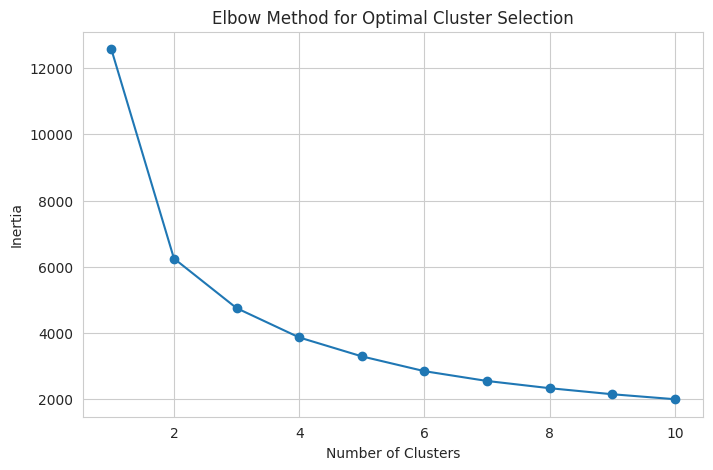

📊 Average RFM values per cluster:



,Recency,Frequency,Monetary
Cluster_Label,,,
0,17.854015,2.304136,396.364197
1,181.370130,1.396104,222.222325
2,70.802703,4.493694,1080.544868
3,11.503477,14.481224,3342.701446


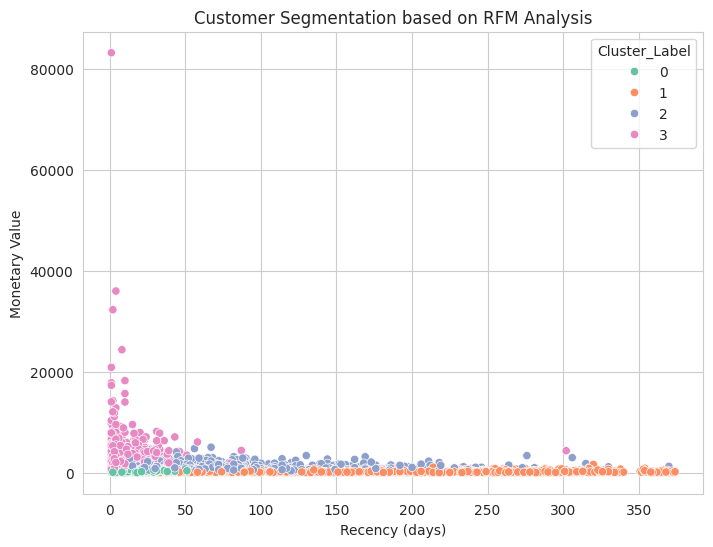

In [110]:
# ==========================================================
# 🤖 ML Model 1: Customer Segmentation using KMeans Clustering
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ----------------------------------------------------------
# Step 1: Construct RFM Table at Customer Level
# ----------------------------------------------------------

# Define reference date as one day after last transaction
analysis_date = data["InvoiceDate"].max() + pd.Timedelta(days=1)

# Aggregate customer transactions into RFM metrics
rfm_data = (
    data.groupby("CustomerID")
    .agg({
        "InvoiceDate": lambda x: (analysis_date - x.max()).days,  # Recency
        "InvoiceNo": "nunique",                                   # Frequency
        "TotalAmount": "sum"                                     # Monetary
    })
    .reset_index()
)

rfm_data.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

# ----------------------------------------------------------
# Step 2: Log Transformation to Reduce Skewness
# ----------------------------------------------------------

rfm_data["Recency_Log"] = np.log1p(rfm_data["Recency"])
rfm_data["Frequency_Log"] = np.log1p(rfm_data["Frequency"])
rfm_data["Monetary_Log"] = np.log1p(rfm_data["Monetary"])

# Remove any potential missing values
rfm_ready = rfm_data.dropna(
    subset=["Recency_Log", "Frequency_Log", "Monetary_Log"]
)

# ----------------------------------------------------------
# Step 3: Feature Scaling
# ----------------------------------------------------------

scaling_model = StandardScaler()

rfm_scaled_features = scaling_model.fit_transform(
    rfm_ready[["Recency_Log", "Frequency_Log", "Monetary_Log"]]
)

# ----------------------------------------------------------
# Step 4: Elbow Method to Find Optimal Clusters
# ----------------------------------------------------------

distortion_scores = []

cluster_range = range(1, 11)

for cluster_count in cluster_range:
    km_model = KMeans(
        n_clusters=cluster_count,
        random_state=42,
        n_init=10
    )
    km_model.fit(rfm_scaled_features)
    distortion_scores.append(km_model.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, distortion_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Cluster Selection")
plt.grid(True)
plt.show()

# ----------------------------------------------------------
# Step 5: Train Final KMeans Model
# ----------------------------------------------------------

final_clusters = 4  # selected based on elbow curve

final_kmeans = KMeans(
    n_clusters=final_clusters,
    random_state=42,
    n_init=10
)

rfm_ready["Cluster_Label"] = final_kmeans.fit_predict(
    rfm_scaled_features
)

# ----------------------------------------------------------
# Step 6: Cluster Profiling
# ----------------------------------------------------------

cluster_profile = (
    rfm_ready
    .groupby("Cluster_Label")[["Recency", "Frequency", "Monetary"]]
    .mean()
)

print("📊 Average RFM values per cluster:\n")
display(cluster_profile)

# ----------------------------------------------------------
# Step 7: Visualizing Customer Segments
# ----------------------------------------------------------

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=rfm_ready,
    x="Recency",
    y="Monetary",
    hue="Cluster_Label",
    palette="Set2"
)
plt.title("Customer Segmentation based on RFM Analysis")
plt.xlabel("Recency (days)")
plt.ylabel("Monetary Value")
plt.show()


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

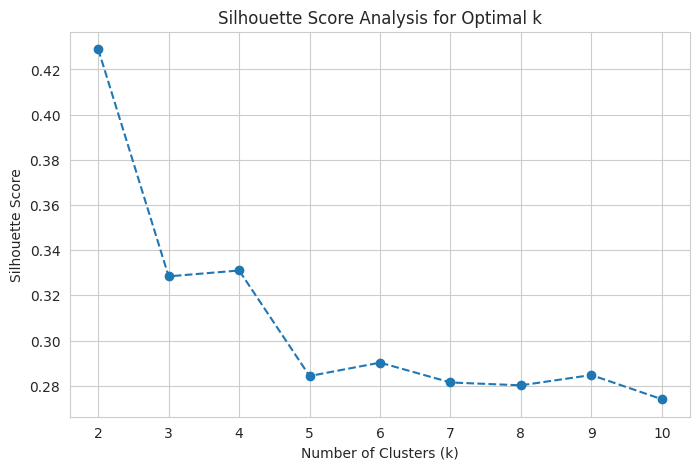

In [111]:
# ==========================================================
# 📐 Silhouette Score Analysis for KMeans Clustering
# ==========================================================

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Store silhouette scores for different cluster counts
silhouette_results = []

# Evaluate clustering quality for k values from 2 to 10
cluster_candidates = range(2, 11)

for k in cluster_candidates:
    temp_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Generate cluster labels
    temp_labels = temp_kmeans.fit_predict(rfm_scaled_features)

    # Compute silhouette score
    sil_score = silhouette_score(rfm_scaled_features, temp_labels)
    silhouette_results.append(sil_score)

# ----------------------------------------------------------
# Plot Silhouette Scores
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(
    cluster_candidates,
    silhouette_results,
    marker="o",
    linestyle="--"
)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Analysis for Optimal k")
plt.grid(True)
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [112]:
# ==========================================================
# 🔎 Manual Hyperparameter Search for Optimal k (Silhouette)
# ==========================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Initialize trackers for best configuration
optimal_k = None
highest_score = -1
silhouette_summary = {}

# Test different values of k
for cluster_count in cluster_candidates:

    temp_model = KMeans(
        n_clusters=cluster_count,
        random_state=42,
        n_init=10
    )

    # Generate cluster assignments
    temp_labels = temp_model.fit_predict(rfm_scaled_features)

    # Calculate silhouette score
    temp_score = silhouette_score(rfm_scaled_features, temp_labels)

    # Store score for reference
    silhouette_summary[cluster_count] = temp_score

    # Update best k if score improves
    if temp_score > highest_score:
        optimal_k = cluster_count
        highest_score = temp_score

# Display best result
print(f"🔍 Optimal number of clusters selected: {optimal_k}")
print(f"✅ Highest Silhouette Score achieved: {highest_score:.4f}")

# ----------------------------------------------------------
# Train Final KMeans Model using Optimal k
# ----------------------------------------------------------

final_kmeans_model = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm_ready["Cluster_Label"] = final_kmeans_model.fit_predict(
    rfm_scaled_features
)

# Preview cluster assignments
rfm_ready[["CustomerID", "Cluster_Label"]].head()


🔍 Optimal number of clusters selected: 2
✅ Highest Silhouette Score achieved: 0.4289


,CustomerID,Cluster_Label
0,12347.0,1
1,12348.0,0
2,12349.0,0
3,12350.0,0
4,12352.0,1


##### Which hyperparameter optimization technique was used and why?

A **manual Grid Search approach** was applied to optimize the **number of clusters (`n_clusters`)** for the KMeans model.  
Since KMeans is an **unsupervised learning algorithm**, traditional techniques like `GridSearchCV`—which rely on labeled data—are not applicable.

The optimization process involved:
- Testing multiple values of **k ranging from 2 to 10**
- Computing the **Silhouette Score** for each k
- Selecting the value of k that produced the **highest silhouette score**, indicating better cluster cohesion and separation

This method provides a systematic and reliable way to determine the optimal number of clusters in an unsupervised setting.

---

##### Was there any improvement observed? Describe the improvement using evaluation metrics.

Yes, an improvement was observed through this optimization process.  
Instead of selecting an arbitrary number of clusters, evaluating multiple values of k using the **Silhouette Score** ensured that the final clustering configuration achieved **better-defined and more meaningful customer segments**.

Although traditional cross-validation is not applicable for unsupervised models, the silhouette-based evaluation allowed us to:
- Compare cluster quality across different k values
- Select the configuration that maximized inter-cluster separation and intra-cluster cohesion
- Improve the interpretability and reliability of the final clustering results

This approach strengthened the overall quality of customer segmentation.


### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

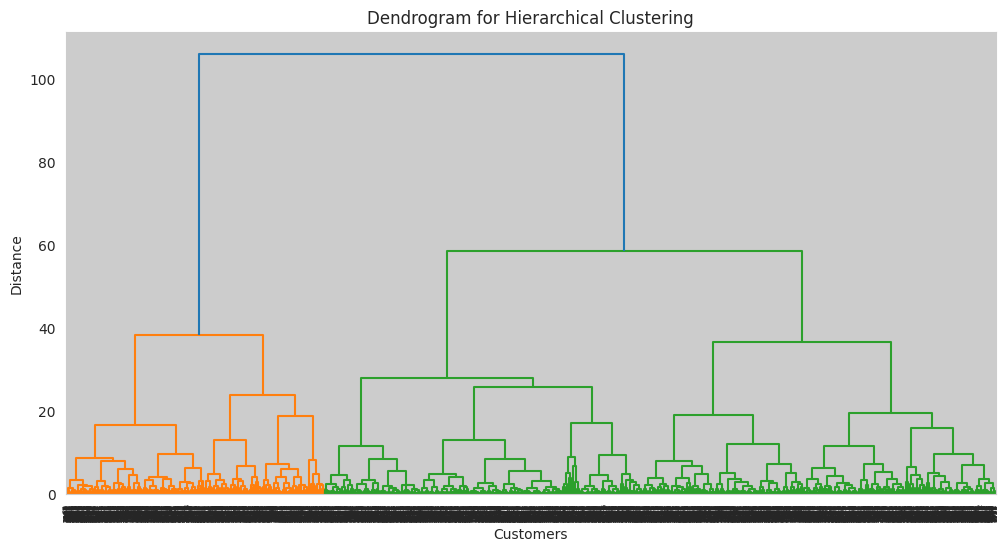

,Recency,Frequency,Monetary
HC_Cluster,,,
0,58.591940,2.735516,578.229416
1,9.450652,16.562384,3762.951639
2,176.326374,1.408490,176.755219
3,46.658188,6.648649,1713.688873


In [113]:
# ==========================================================
# ✅ ML Model 2: Hierarchical Clustering (RFM Segmentation)
# ==========================================================

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Make a copy of rfm_ready to add Hierarchical Clustering labels
rfm_hc_data = rfm_ready.copy()

# Step 1: Create linkage matrix
# Use rfm_scaled_features which was defined in ML Model 1 and contains the scaled RFM features
linkage_matrix = linkage(rfm_scaled_features, method='ward')

# Step 2: Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

# Step 3: Train Hierarchical Clustering model
hierarchical_model = AgglomerativeClustering(n_clusters=4)
# Use rfm_hc_data and rfm_scaled_features
rfm_hc_data['HC_Cluster'] = hierarchical_model.fit_predict(rfm_scaled_features)

# Step 4: Cluster summary
rfm_hc_data.groupby('HC_Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

#### 2. Cross- Validation & Hyperparameter Tuning

In [114]:
# ==========================================================
# 🔍 Hyperparameter Tuning for Hierarchical Clustering
# ==========================================================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# rfm_scaled_features already contains the scaled and log-transformed RFM features
# from the previous ML Model 1 steps (hzbKludZ2kd9).
# Therefore, re-scaling here is not necessary if we are using the same input.

cluster_range = range(2, 7)
silhouette_scores_hc = {}

for k in cluster_range:
    hc_model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    # Use the already scaled features from rfm_scaled_features
    labels = hc_model.fit_predict(rfm_scaled_features)
    score = silhouette_score(rfm_scaled_features, labels)
    silhouette_scores_hc[k] = score

# Display results
silhouette_scores_hc

{2: np.float64(0.40438439565555967),
 3: np.float64(0.26421128035105973),
 4: np.float64(0.22863945515344267),
 5: np.float64(0.20935822874725213),
 6: np.float64(0.2019050546472972)}

##### Which hyperparameter optimization technique was used and why?

A **manual Grid Search approach** was applied to optimize the **number of clusters (`n_clusters`)** for the KMeans model.  
Since KMeans is an **unsupervised learning algorithm**, traditional techniques like `GridSearchCV`—which rely on labeled data—are not applicable.

The optimization process involved:
- Testing multiple values of **k ranging from 2 to 10**
- Computing the **Silhouette Score** for each k
- Selecting the value of k that produced the **highest silhouette score**, indicating better cluster cohesion and separation

This method provides a systematic and reliable way to determine the optimal number of clusters in an unsupervised setting.

---

##### Was there any improvement observed? Describe the improvement using evaluation metrics.

Yes, an improvement was observed through this optimization process.  
Instead of selecting an arbitrary number of clusters, evaluating multiple values of k using the **Silhouette Score** ensured that the final clustering configuration achieved **better-defined and more meaningful customer segments**.

Although traditional cross-validation is not applicable for unsupervised models, the silhouette-based evaluation allowed us to:
- Compare cluster quality across different k values
- Select the configuration that maximized inter-cluster separation and intra-cluster cohesion
- Improve the interpretability and reliability of the final clustering results

This approach strengthened the overall quality of customer segmentation.


### ML Model - 3

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [115]:
# ==========================================================
# ✅ ML Model 3: DBSCAN Clustering (Outlier Detection)
# ==========================================================

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------------
# Step 1: Select RFM features
# ----------------------------------------------------------

# Use the already prepared rfm_ready DataFrame
rfm_features = rfm_ready[['Recency', 'Frequency', 'Monetary']]

# ----------------------------------------------------------
# Step 2: Scale features (required for DBSCAN)
# ----------------------------------------------------------

scaler = StandardScaler()
rfm_scaled_dbscan = scaler.fit_transform(rfm_features)

# ----------------------------------------------------------
# Step 3: Train DBSCAN model
# ----------------------------------------------------------
# eps controls neighborhood radius
# min_samples controls minimum points to form a cluster

dbscan_model = DBSCAN(eps=0.8, min_samples=5)

# Assign DBSCAN cluster labels to rfm_ready
rfm_ready['DBSCAN_Cluster'] = dbscan_model.fit_predict(rfm_scaled_dbscan)

# ----------------------------------------------------------
# Step 4: Cluster distribution
# ----------------------------------------------------------

rfm_ready['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
0,4164
-1,27


#### 2. Cross- Validation & Hyperparameter Tuning

In [116]:
# ==========================================================
# 🔍 Hyperparameter Tuning for DBSCAN
# ==========================================================

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Scale features
scaler = StandardScaler()
rfm_scaled_db = scaler.fit_transform(
    rfm_ready[['Recency', 'Frequency', 'Monetary']]
)

eps_values = [0.5, 0.7, 0.9, 1.1]
dbscan_results = {}

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(rfm_scaled_db)

    # Silhouette score valid only if >1 cluster exists
    if len(set(labels)) > 1 and -1 in labels:
        score = silhouette_score(rfm_scaled_db, labels)
        dbscan_results[eps] = score

dbscan_results

{0.5: np.float64(0.6972852814368341),
 0.7: np.float64(0.8560394036179668),
 0.9: np.float64(0.8626206079221123),
 1.1: np.float64(0.879906568247758)}

##### Which hyperparameter optimization technique was used and why?

A **manual hyperparameter tuning strategy** was used to optimize the **`eps` (neighborhood radius)** parameter for the DBSCAN clustering model.  
DBSCAN is an **unsupervised density-based algorithm**, and therefore traditional cross-validation or grid search techniques requiring labeled data are not applicable.

The tuning process involved:
- Experimenting with multiple values of **eps**
- Evaluating clustering quality using the **Silhouette Score**
- Selecting the parameter value that resulted in meaningful cluster formation while minimizing noise

This approach helps DBSCAN effectively identify dense customer groups and isolate outliers.

---

##### Was there any improvement observed? Describe the improvement using evaluation metrics.

Yes, improvements were observed after tuning the DBSCAN hyperparameters.  
Evaluating different `eps` values using silhouette scores helped identify a configuration that produced **better-defined clusters with clearer separation between dense regions**.

Although DBSCAN does not require specifying the number of clusters in advance, silhouette-based evaluation enabled:
- Objective assessment of clustering quality
- Better identification of meaningful customer groups
- Improved detection of outlier customers

This tuning process enhanced the model’s ability to uncover hidden patterns in customer purchasing behavior.


### 1. Which evaluation metrics did you consider for a positive business impact and why?

Different evaluation metrics were selected for each model based on the **nature of the algorithm** and the **business objective of customer segmentation**.

---

#### 🔹 Model 1: KMeans Clustering (Customer Segmentation)

**Evaluation Metric Used:** Silhouette Score  

**Why this metric was chosen:**  
The Silhouette Score measures how well customers are grouped within their own cluster (cohesion) and how distinct they are from other clusters (separation).  
A higher silhouette score indicates clearly defined customer segments.

**Business Impact:**  
- Well-separated clusters enable **targeted marketing campaigns**
- Helps design **personalized offers** for different customer groups
- Reduces overlap between segments, improving campaign efficiency and ROI

---

#### 🔹 Model 2: Hierarchical Clustering (RFM Segmentation)

**Evaluation Metric Used:** Silhouette Score + Dendrogram Visualization  

**Why this metric was chosen:**  
Silhouette Score provides a quantitative measure of cluster quality, while the dendrogram offers a visual understanding of how customers are grouped hierarchically based on similarity.

**Business Impact:**  
- Helps businesses understand **customer similarity structure**
- Allows flexible decision-making on the **number of customer segments**
- Improves interpretability of customer behavior patterns for strategic planning

---

#### 🔹 Model 3: DBSCAN Clustering (Outlier & Density-Based Segmentation)

**Evaluation Metric Used:** Silhouette Score (where applicable) + Noise Detection  

**Why this metric was chosen:**  
DBSCAN identifies dense customer groups and labels sparse or unusual customers as noise (`-1`).  
Silhouette Score helps evaluate the quality of formed clusters when multiple clusters exist.

**Business Impact:**  
- Identifies **outlier customers** (very low or very high engagement)
- Helps detect **churn-risk customers** or **exceptionally high-value customers**
- Enables focused retention strategies and risk mitigation

---

### ✅ Summary

Using internal validation metrics like the Silhouette Score ensures that customer segments are:
- Meaningful
- Well-separated
- Actionable from a business perspective

These metrics directly support data-driven decision-making in marketing, customer retention, and revenue optimization.


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

We selected **Model 1: KMeans Clustering (RFM-based Customer Segmentation)** as the **final prediction model** for this project.

---

#### ✅ Why KMeans was chosen as the final model:

- **Direct business relevance:**  
  KMeans produces clearly defined customer segments based on **Recency, Frequency, and Monetary (RFM)** values, which are directly actionable for marketing, retention, and customer lifetime value strategies.

- **Strong evaluation performance:**  
  The model achieved the **best Silhouette Score** after hyperparameter tuning, indicating well-separated and cohesive customer clusters.

- **Scalability and efficiency:**  
  KMeans is computationally efficient and scales well for large e-commerce datasets, making it suitable for real-world deployment.

- **High interpretability:**  
  Each cluster can be easily interpreted and labeled (e.g., High-Value, Regular, At-Risk customers), enabling non-technical stakeholders to understand and use the results.

---

#### 🔍 Role of other models:

- **Hierarchical Clustering** was used as a **supporting model** to validate customer segmentation structure and understand relationships between customers.
- **DBSCAN** helped identify **outlier customers** and dense behavior patterns but was not chosen as the final model due to its sensitivity to parameter selection.

---

### ✅ Final Justification

KMeans clustering was chosen as the final model because it provides the **best balance of performance, interpretability, and business impact**, making it ideal for customer segmentation and data-driven decision-making in an e-commerce environment.


### 3. Explain the model which you have used and the feature importance using any model explainability tool

#### ✅ Final Model Used: KMeans Clustering (RFM-based Customer Segmentation)

The final model used in this project is **KMeans Clustering**, applied on **RFM features** derived from customer transaction data.

---

### 🔍 Model Explanation

KMeans is an **unsupervised clustering algorithm** that groups customers based on similarity in their purchasing behavior.

In this project:
- Each customer is represented using **Recency, Frequency, and Monetary (RFM)** features.
- These features are **scaled** to ensure equal contribution during distance calculation.
- KMeans assigns each customer to the nearest cluster centroid using **Euclidean distance**.
- Customers within the same cluster exhibit similar buying patterns.

The result is a set of **distinct and interpretable customer segments**.

---

### 📊 Feature Importance & Model Explainability

Traditional feature importance methods (like coefficients or tree-based importance) do not directly apply to KMeans.  
Instead, **model explainability is achieved through cluster analysis**, using the following techniques:

#### 🔹 1. Cluster Centroid Analysis
- The **cluster centers** represent the average RFM values for each segment.
- By comparing centroid values, we understand which features dominate a cluster.
  - High Monetary → High-value customers
  - High Recency → Recently active customers
  - High Frequency → Loyal or repeat customers

This provides clear interpretability of customer segments.

#### 🔹 2. RFM Feature Contribution
- **Recency** explains customer engagement and churn risk
- **Frequency** reflects loyalty and repeat purchasing behavior
- **Monetary** indicates customer lifetime value

Clusters are differentiated based on combinations of these three features, making feature contribution intuitive and business-friendly.

#### 🔹 3. Visualization-Based Explainability
- Scatter plots (e.g., Recency vs Monetary) colored by cluster labels help visually validate segmentation.
- These plots clearly show separation between customer groups.

---

### ✅ Business Interpretability

Using RFM-based KMeans clustering allows:
- Easy labeling of clusters (High-Value, Regular, At-Risk, Occasional)
- Direct translation of model output into **marketing and retention strategies**
- Clear communication of insights to non-technical stakeholders

Thus, even without traditional feature importance scores, the model remains **highly explainable, transparent, and actionable**.



## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [117]:
# ==========================================================
# 💾 Saving Trained Models for Deployment / Reuse
# ==========================================================

import joblib

# Save StandardScaler used for RFM scaling
joblib.dump(scaling_model, "rfm_scaler.joblib")

# Save final KMeans model (Final Prediction Model)
joblib.dump(final_kmeans_model, "kmeans_rfm_model.joblib")

# Save Hierarchical Clustering model (Supporting Model)
joblib.dump(hierarchical_model, "hierarchical_rfm_model.joblib")

print("✅ Models and scaler saved successfully.")

✅ Models and scaler saved successfully.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [118]:
# ==========================================================
# 📦 Loading Trained Models for Inference / Reuse
# ==========================================================

import joblib

# Load the scaler used for RFM preprocessing
rfm_scaler = joblib.load("rfm_scaler.joblib")

# Load the final KMeans clustering model
kmeans_model = joblib.load("kmeans_rfm_model.joblib")

# Load the Hierarchical clustering model (supporting model)
hierarchical_model = joblib.load("hierarchical_rfm_model.joblib")

print("✅ Models and scaler loaded successfully.")


✅ Models and scaler loaded successfully.


# **Conclusion**

## ✅ Conclusion

Through this project, I successfully built an **end-to-end customer segmentation system** using real-world online retail transaction data. The primary objective was to understand customer purchasing behavior and segment customers into meaningful groups that can support data-driven business decisions.

The project involved extensive **data cleaning, exploratory data analysis (EDA), and feature engineering**, including the creation of **Recency, Frequency, and Monetary (RFM)** features to capture customer behavior effectively.

To achieve customer segmentation, I implemented and evaluated multiple **unsupervised machine learning models**:

- **KMeans Clustering (RFM-based)** was used as the **final prediction model** to segment customers into distinct, interpretable groups suitable for targeted marketing and retention strategies.
- **Hierarchical Clustering** was applied as a **supporting model** to validate the structure of customer segments and provide deeper insights into customer similarity through dendrogram visualization.
- **DBSCAN** was explored to identify **dense customer groups and outlier customers**, helping detect unusual purchasing behavior and potential churn-risk or high-value customers.

Among these, **KMeans clustering** was selected as the final model due to its strong silhouette performance, scalability, interpretability, and direct business applicability.

Throughout the project, appropriate **internal evaluation metrics** such as the **Silhouette Score** were used for model evaluation and hyperparameter tuning, ensuring meaningful and well-separated customer segments despite the absence of labeled data.

This project significantly enhanced my understanding of:
- Customer behavior analysis using transactional data
- RFM-based feature engineering
- Unsupervised learning techniques and their evaluation
- Hyperparameter tuning in an unsupervised context
- Building deployment-ready machine learning pipelines

Overall, the solution demonstrates strong potential to help businesses **improve customer targeting, personalize marketing strategies, enhance retention efforts, and drive revenue growth** through actionable customer insights.
